<a href="https://colab.research.google.com/github/SBPat-123/iKineticsInternship/blob/main/HistoricalDataAnalyse_ipnyb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Install Libraries

In [ ]:
# Installs the xgboost library if not already present.
!pip install xgboost

### Upload Data File

In [ ]:
# Uploads the 'HistoricalSupplierData.xlsx' file from the local system to the Colab environment.
from google.colab import files
uploaded = files.upload()

Saving HistoricalSupplierData.xlsx to HistoricalSupplierData.xlsx


### Load Data into DataFrame

In [ ]:
# Imports the pandas library and loads the uploaded Excel file into a pandas DataFrame named 'df'.
import pandas as pd
df = pd.read_excel("HistoricalSupplierData.xlsx")

### Data Preparation, Feature Engineering, and LEAD_TIME_RATIO Prediction Model Training

This cell performs data cleaning, feature engineering, and trains an XGBoost Regressor to predict the `LEAD_TIME_RATIO`.

In [ ]:
# This cell performs comprehensive data cleaning, feature engineering, model training for LEAD_TIME_RATIO prediction, and data splitting.
# It standardizes column names, converts categorical data, calculates lead times, imputes missing values, aggregates vendor-specific historical features,
# selects features for the model, splits data into training and testing sets, and trains an XGBoost Regressor for LEAD_TIME_RATIO prediction.
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor, XGBClassifier

df = pd.read_excel("HistoricalSupplierData.xlsx")

def clean_col_names(df):
    original_cols = df.columns
    new_cols_list = []
    seen_names_count = {}
    for col in original_cols:
        cleaned_name = col.replace('/', '_').replace(' ', '_').replace('(', '').replace(')', '').replace('.', '').replace('-', '_').replace('%', '').upper()

        if cleaned_name in seen_names_count:
            seen_names_count[cleaned_name] += 1
            final_name = f"{cleaned_name}_{seen_names_count[cleaned_name]}"
        else:
            seen_names_count[cleaned_name] = 0
            final_name = cleaned_name
        new_cols_list.append(final_name)
    df.columns = new_cols_list
    return df

df = clean_col_names(df)

if '6_MONTHS_YES_NO_MONTHLY_OTD' in df.columns:
    df.rename(columns={'6_MONTHS_YES_NO_MONTHLY_OTD': 'X6_MONTH_TOTAL_CORRECTED_OTD'}, inplace=True)

if 'X6_MONTH_TOTAL_CORRECTED_OTD' in df.columns:
    df['X6_MONTH_TOTAL_CORRECTED_OTD'] = df['X6_MONTH_TOTAL_CORRECTED_OTD'].map({'Yes': 1, 'No': 0})
    df['X6_MONTH_TOTAL_CORRECTED_OTD'] = df['X6_MONTH_TOTAL_CORRECTED_OTD'].fillna(df['X6_MONTH_TOTAL_CORRECTED_OTD'].median() if not pd.isna(df['X6_MONTH_TOTAL_CORRECTED_OTD'].median()) else 0)

df['SCHED_LINE_CRT_DATE'] = pd.to_datetime(df['SCHED_LINE_CRT_DATE'], errors='coerce')
df['DELIVERY_DATE'] = pd.to_datetime(df['DELIVERY_DATE'], errors='coerce')

df['ACTUAL_LEAD_TIME_DAYS'] = (df['DELIVERY_DATE'] - df['SCHED_LINE_CRT_DATE']).dt.days

median_planned_delivery = df['PLANNED_DELIVERY_TIME_IN_DAYS'].median()
df['PLANNED_DELIVERY_TIME_IN_DAYS'] = df['PLANNED_DELIVERY_TIME_IN_DAYS'].fillna(median_planned_delivery if not pd.isna(median_planned_delivery) else 30)

df['LEAD_TIME_RATIO'] = df.apply(lambda row:
    row['ACTUAL_LEAD_TIME_DAYS'] / row['PLANNED_DELIVERY_TIME_IN_DAYS']
    if row['PLANNED_DELIVERY_TIME_IN_DAYS'] > 0 else 0, axis=1
)

df['SCHED_LINE_CRT_MONTH'] = df['SCHED_LINE_CRT_DATE'].dt.month
df['SCHED_LINE_CRT_DAY_OF_WEEK'] = df['SCHED_LINE_CRT_DATE'].dt.dayofweek
df['SCHED_LINE_CRT_YEAR'] = df['SCHED_LINE_CRT_DATE'].dt.year

vendor_performance_cols = ['X6_MONTH_TOTAL_CORRECTED_OTD', 'TOTAL_MISS']

for col in vendor_performance_cols:
    if col in df.columns:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val if not pd.isna(median_val) else 0)

vendor_aggregates = df.groupby('VENDOR_NAME').agg(
    AVG_ACTUAL_LEAD_TIME_DAYS=('ACTUAL_LEAD_TIME_DAYS', 'mean'),
    STD_ACTUAL_LEAD_TIME_DAYS=('ACTUAL_LEAD_TIME_DAYS', 'std'),
    TOTAL_ORDERS=('VENDOR_NAME', 'count'),
    AVG_LEAD_TIME_RATIO_VENDOR=('LEAD_TIME_RATIO', 'mean')
).reset_index()

vendor_aggregates['STD_ACTUAL_LEAD_TIME_DAYS'] = vendor_aggregates['STD_ACTUAL_LEAD_TIME_DAYS'].fillna(0)

df = pd.merge(df, vendor_aggregates, on='VENDOR_NAME', how='left')

def calculate_lateness_score(avg_ratio):
    if avg_ratio <= 1.0:
        return 100.0
    else:
        return max(0.0, 100.0 - (avg_ratio - 1.0) * 100.0)

features = [
    'PLANNED_DELIVERY_TIME_IN_DAYS',
    'X6_MONTH_TOTAL_CORRECTED_OTD',
    'TOTAL_MISS',
    'AVG_ACTUAL_LEAD_TIME_DAYS',
    'STD_ACTUAL_LEAD_TIME_DAYS',
    'TOTAL_ORDERS',
    'AVG_LEAD_TIME_RATIO_VENDOR'
]

features = [col for col in features if col in df.columns]

df_filtered = df.dropna(subset=features + ['LEAD_TIME_RATIO']).copy()

X = df_filtered[features]
y = df_filtered['LEAD_TIME_RATIO']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

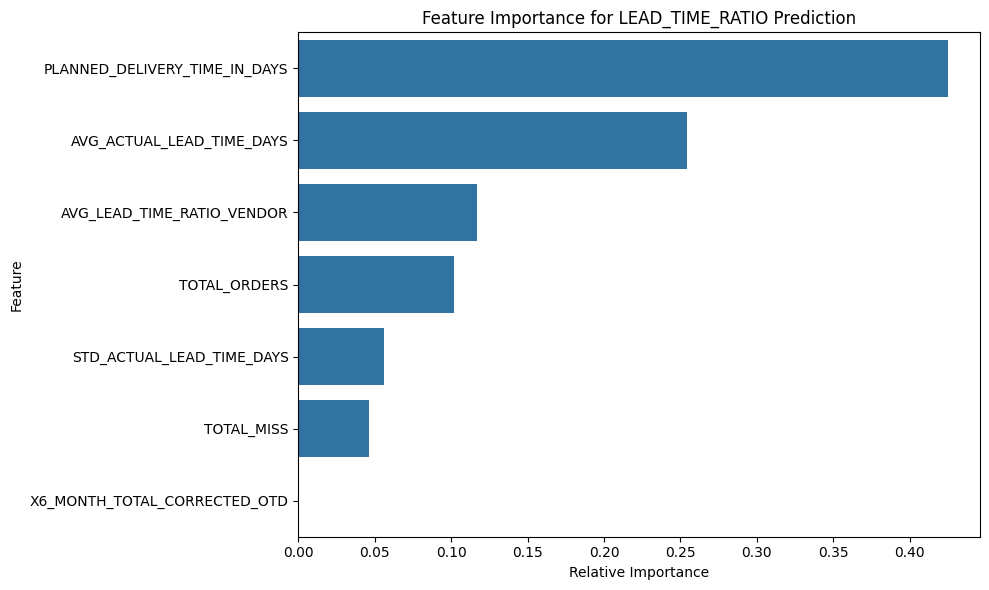

In [ ]:
# This cell visualizes the feature importances from the trained XGBoost Regressor (`xgb_model`).
# It extracts the importance scores for each feature used in predicting the 'LEAD_TIME_RATIO'
# and displays them as a bar plot, showing which features had the most impact on the model's predictions.
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances = xgb_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance for LEAD_TIME_RATIO Prediction')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Calculate Predictability Score

In [ ]:
# This cell calculates the Predictability Score for each supplier.
# It first recalculates the Mean Absolute Error (MAE) for each supplier based on the XGBoost Regressor predictions.
# Then, it normalizes these MAE values and converts them into a Predictability Score from 0 to 100, where a higher score indicates greater predictability.
test_supplier_names = df_filtered.loc[y_test.index, 'VENDOR_NAME']
supplier_performance = pd.DataFrame({
    'VENDOR_NAME': test_supplier_names,
    'Actual_LEAD_TIME_RATIO': y_test,
    'Predicted_LEAD_TIME_RATIO': y_pred
})
supplier_mae = supplier_performance.groupby('VENDOR_NAME').apply(lambda x: mean_absolute_error(x['Actual_LEAD_TIME_RATIO'], x['Predicted_LEAD_TIME_RATIO']), include_groups=False)
supplier_mae_df = supplier_mae.reset_index(name='MAE')
supplier_mae_df = supplier_mae_df.sort_values(by='MAE', ascending=True)

min_mae = supplier_mae_df['MAE'].min()
max_mae = supplier_mae_df['MAE'].max()

if (max_mae - min_mae) == 0:
    supplier_mae_df['Predictability_Score'] = 100.0
else:
    supplier_mae_df['Normalized_MAE'] = (supplier_mae_df['MAE'] - min_mae) / (max_mae - min_mae)
    supplier_mae_df['Predictability_Score'] = (1 - supplier_mae_df['Normalized_MAE']) * 100

### Calculate On-Time Reliability Score

In [ ]:
# This cell calculates the On-Time Reliability Score for each supplier.
# It defines 'ON_TIME_DELIVERY' as a binary target, trains an XGBoost Classifier to predict on-time delivery probability,
# and then calculates the average predicted on-time probability per vendor, converting it into a score from 0 to 100.
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

df_filtered['ON_TIME_DELIVERY'] = (
    (df_filtered['ACTUAL_LEAD_TIME_DAYS'] <= df_filtered['PLANNED_DELIVERY_TIME_IN_DAYS']) &
    (df_filtered['PLANNED_DELIVERY_TIME_IN_DAYS'] > 0)
).astype(int)

X_clf = df_filtered[features]
y_clf = df_filtered['ON_TIME_DELIVERY']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

xgb_clf_model = XGBClassifier(objective='binary:logistic', n_estimators=100, random_state=42, eval_metric='logloss')
xgb_clf_model.fit(X_train_clf, y_train_clf)
y_pred_proba_clf = xgb_clf_model.predict_proba(X_test_clf)[:, 1]

test_supplier_names_clf = df_filtered.loc[y_test_clf.index, 'VENDOR_NAME']
supplier_ontime_performance = pd.DataFrame({
    'VENDOR_NAME': test_supplier_names_clf,
    'Actual_ON_TIME_DELIVERY': y_test_clf,
    'Predicted_ON_TIME_PROBABILITY': y_pred_proba_clf
})
supplier_ontime_reliability_df = supplier_ontime_performance.groupby('VENDOR_NAME')['Predicted_ON_TIME_PROBABILITY'].mean().reset_index()
supplier_ontime_reliability_df['On_Time_Reliability_Score'] = supplier_ontime_reliability_df['Predicted_ON_TIME_PROBABILITY'] * 100

### Calculate Calculated Normal Reliability Score (Lateness Based)

In [ ]:
# This cell calculates the Calculated Normal Reliability Score, which is a lateness-based reliability score derived from the predicted LEAD_TIME_RATIO.
# It uses the previously trained XGBoost Regressor to predict LEAD_TIME_RATIO for all filtered data, averages these predictions per supplier,
# and then applies a lateness scoring function to transform the average predicted ratio into a reliability score.

all_predicted_lead_time_ratio = xgb_model.predict(X)
supplier_lateness_prediction = df_filtered[['VENDOR_NAME']].copy()
supplier_lateness_prediction['Predicted_LEAD_TIME_RATIO'] = all_predicted_lead_time_ratio
average_lateness_per_supplier = supplier_lateness_prediction.groupby('VENDOR_NAME')['Predicted_LEAD_TIME_RATIO'].mean().reset_index()
average_lateness_per_supplier.rename(columns={'Predicted_LEAD_TIME_RATIO': 'Average_Predicted_LEAD_TIME_RATIO'}, inplace=True)

def calculate_lateness_score(avg_ratio):
    if avg_ratio <= 1.0:
        return 100.0
    else:
        return max(0.0, 100.0 - (avg_ratio - 1.0) * 100.0)

average_lateness_per_supplier['Lateness_Based_Reliability_Score'] = average_lateness_per_supplier['Average_Predicted_LEAD_TIME_RATIO'].apply(calculate_lateness_score)
final_lateness_reliability_df = average_lateness_per_supplier.sort_values(by='Lateness_Based_Reliability_Score', ascending=False)

### Calculate Actual On-Time Percentage

In [ ]:
# This cell calculates the actual historical on-time delivery percentage for each vendor.
# It groups the filtered DataFrame by 'VENDOR_NAME' and computes the mean of the 'ON_TIME_DELIVERY' (binary) column,
# then converts this proportion into a percentage.
actual_ontime_percentage = df_filtered.groupby('VENDOR_NAME')['ON_TIME_DELIVERY'].mean().reset_index()
actual_ontime_percentage['Actual_On_Time_Percentage'] = actual_ontime_percentage['ON_TIME_DELIVERY'] * 100
actual_ontime_percentage = actual_ontime_percentage.drop(columns=['ON_TIME_DELIVERY'])

### Calculate Actual Lateness Weighted Reliability Score

In [ ]:
# This cell calculates the Actual Lateness Weighted Reliability Score for each vendor.
# It first determines the average actual LEAD_TIME_RATIO for each vendor from the historical data.
# Then, it applies the previously defined `calculate_lateness_score` function to these average ratios to derive the weighted reliability score.

average_actual_lead_time_ratio = df_filtered.groupby('VENDOR_NAME')['LEAD_TIME_RATIO'].mean().reset_index()
average_actual_lead_time_ratio.rename(columns={'LEAD_TIME_RATIO': 'Average_Actual_LEAD_TIME_RATIO'}, inplace=True)
average_actual_lead_time_ratio['Actual_Lateness_Weighted_Reliability_Score'] = average_actual_lead_time_ratio['Average_Actual_LEAD_TIME_RATIO'].apply(calculate_lateness_score)
actual_lateness_reliability_df = average_actual_lead_time_ratio.sort_values(by='Actual_Lateness_Weighted_Reliability_Score', ascending=False)

### Calculate Predicted Normal Reliability Score

In [ ]:
# This cell focuses on calculating the Predicted Normal Reliability Score using a second XGBoost Regressor.
# It renames the 'Lateness_Based_Reliability_Score' to 'Calculated_Normal_Reliability_Score',
# aggregates vendor-level features, merges them with the calculated score, trains a new XGBoost Regressor with these aggregated features,
# and then predicts the 'Predicted_Normal_Reliability_Score' for all vendors.

final_lateness_reliability_df = final_lateness_reliability_df.rename(columns={'Lateness_Based_Reliability_Score': 'Calculated_Normal_Reliability_Score'})

vendor_level_features_for_reliability_model = [
    'PLANNED_DELIVERY_TIME_IN_DAYS',
    'X6_MONTH_TOTAL_CORRECTED_OTD',
    'TOTAL_MISS',
    'AVG_ACTUAL_LEAD_TIME_DAYS',
    'STD_ACTUAL_LEAD_TIME_DAYS',
    'TOTAL_ORDERS',
    'AVG_LEAD_TIME_RATIO_VENDOR'
]

vendor_level_features_for_reliability_model = [col for col in vendor_level_features_for_reliability_model if col in df_filtered.columns]

vendor_features_for_reliability_model = df_filtered.groupby('VENDOR_NAME')[vendor_level_features_for_reliability_model].mean().reset_index()

vendor_reliability_data = pd.merge(
    final_lateness_reliability_df[['VENDOR_NAME', 'Calculated_Normal_Reliability_Score']],
    vendor_features_for_reliability_model,
    on='VENDOR_NAME',
    how='inner'
)

X_for_training_prediction = vendor_reliability_data[vendor_level_features_for_reliability_model]
y_for_training_prediction = vendor_reliability_data['Calculated_Normal_Reliability_Score']

xgb_reliability_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_reliability_model.fit(X_for_training_prediction, y_for_training_prediction)

vendor_reliability_data['Predicted_Normal_Reliability_Score'] = xgb_reliability_model.predict(X_for_training_prediction)

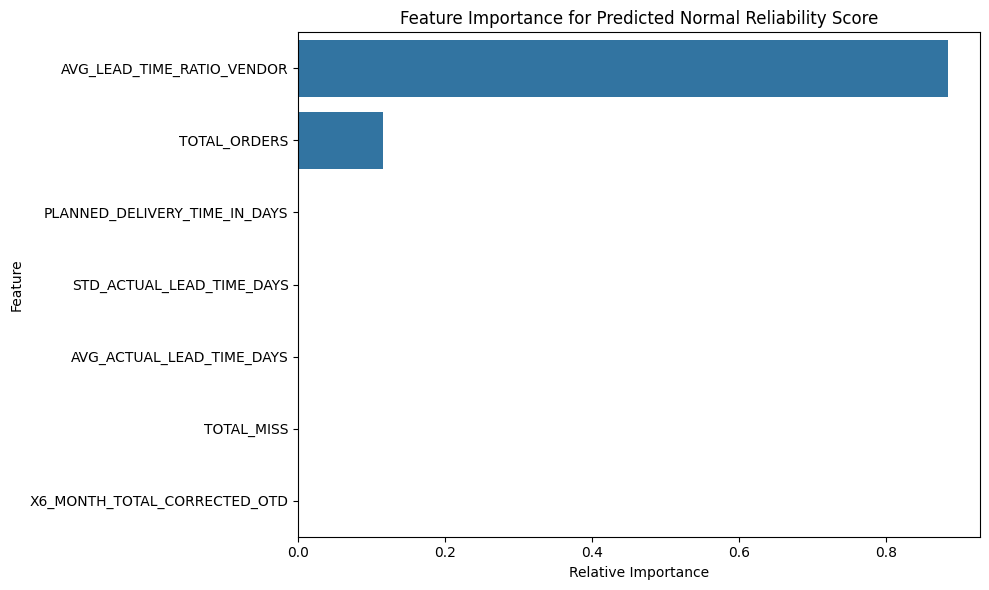

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained XGBoost Regressor for reliability score
feature_importances_reliability = xgb_reliability_model.feature_importances_

# Create a DataFrame for better visualization
importance_df_reliability = pd.DataFrame({
    'Feature': vendor_level_features_for_reliability_model, # Features used by xgb_reliability_model
    'Importance': feature_importances_reliability
}).sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df_reliability)
plt.title('Feature Importance for Predicted Normal Reliability Score')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Consolidate and Display All Reliability Scores

In [ ]:
# This cell merges all the individual reliability scores calculated previously into a single, consolidated DataFrame named `all_scores`.
# It then reorders the columns for better readability and sorts the final table by 'Predicted_Normal_Reliability_Score' in descending order before displaying it.
import pandas as pd

all_scores = supplier_mae_df[['VENDOR_NAME', 'Predictability_Score']].copy()

all_scores = pd.merge(
    all_scores,
    supplier_ontime_reliability_df[['VENDOR_NAME', 'On_Time_Reliability_Score']],
    on='VENDOR_NAME',
    how='left'
)

all_scores = pd.merge(
    all_scores,
    vendor_reliability_data[['VENDOR_NAME', 'Calculated_Normal_Reliability_Score', 'Predicted_Normal_Reliability_Score']],
    on='VENDOR_NAME',
    how='left'
)

all_scores = pd.merge(
    all_scores,
    actual_ontime_percentage[['VENDOR_NAME', 'Actual_On_Time_Percentage']],
    on='VENDOR_NAME',
    how='left'
)

all_scores = pd.merge(
    all_scores,
    actual_lateness_reliability_df[['VENDOR_NAME', 'Actual_Lateness_Weighted_Reliability_Score']],
    on='VENDOR_NAME',
    how='left'
)

desired_column_order = [
    'VENDOR_NAME',
    'Actual_On_Time_Percentage',
    'Actual_Lateness_Weighted_Reliability_Score',
    'On_Time_Reliability_Score',
    'Calculated_Normal_Reliability_Score',
    'Predicted_Normal_Reliability_Score',
    'Predictability_Score'
]

all_scores = all_scores[desired_column_order]

all_scores = all_scores.sort_values(by='Predicted_Normal_Reliability_Score', ascending=False).reset_index(drop=True)

display(all_scores)

,VENDOR_NAME,Actual_On_Time_Percentage,Actual_Lateness_Weighted_Reliability_Score,On_Time_Reliability_Score,Calculated_Normal_Reliability_Score,Predicted_Normal_Reliability_Score,Predictability_Score
0,FUTURETECH ENGINEERING LLP,83.333333,100.000000,84.637665,100.000000,100.000183,83.128798
1,"AEQUS AERO MACHINE, INC",100.000000,100.000000,99.976196,100.000000,100.000183,75.287411
2,GLASTRONIX LLP,100.000000,100.000000,99.839851,100.000000,100.000000,94.455869
3,STERLING SPRING LLC,100.000000,100.000000,99.931129,100.000000,100.000000,85.690064
4,UNITED MACHINE CO,100.000000,100.000000,99.968788,100.000000,100.000000,90.503579
5,ROOTS INDUSTRIES INDIA PRIVATE,95.901639,100.000000,93.601547,100.000000,100.000000,88.791190
6,HICAL TECHNOLOGIES PVT LTD,98.260870,100.000000,99.873558,100.000000,100.000000,89.250712
7,JAMAICA BEARINGS COMPANY INC,98.207885,100.000000,98.082993,100.000000,100.000000,87.423228
8,4M INDUSTRIES INC,73.972603,100.000000,73.791054,100.000000,100.000000,86.443231
9,RBC BEARING,97.058824,100.000000,96.668640,100.000000,100.000000,86.201916


In [ ]:
excel_file_path = 'all_reliability_scores.xlsx'
all_scores.to_excel(excel_file_path, index=False)
print(f"DataFrame saved to {excel_file_path}")

DataFrame saved to all_reliability_scores.xlsx


### Download Consolidated Reliability Scores

You can download the `all_reliability_scores.xlsx` file using the link below:

[Download all_reliability_scores.xlsx](all_reliability_scores.xlsx)

In [ ]:
from google.colab import files
files.download(excel_file_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Explanation of Reliability Scores

Here's a breakdown of each column in the `all_scores` DataFrame, detailing its calculation, how variables affected it, and which variables were primarily used for its prediction.

### 1. `VENDOR_NAME`

*   **Calculation:** This is simply the unique identifier for each supplier.
*   **Variables Affected:** N/A (it's the grouping key).
*   **Main Prediction Variables:** N/A.
*   **Reliability:** It's a direct identifier, so its 'reliability' is in its uniqueness and accuracy as a key.

### 2. `Actual_On_Time_Percentage`

*   **Calculation:** This is a non-ML derived score representing the historical percentage of on-time deliveries for each vendor.
    *   `ON_TIME_DELIVERY` was defined as `ACTUAL_LEAD_TIME_DAYS <= PLANNED_DELIVERY_TIME_IN_DAYS` (and `PLANNED_DELIVERY_TIME_IN_DAYS > 0`).
    *   For each vendor, the `mean()` of this binary `ON_TIME_DELIVERY` column was taken and multiplied by 100.
*   **Variables Affected:** Directly reflects the historical `ACTUAL_LEAD_TIME_DAYS` and `PLANNED_DELIVERY_TIME_IN_DAYS` for each vendor.
*   **Main Prediction Variables:** N/A (this is a historical, actual metric, not a prediction).
*   **Reliability:** High. It's based on observed historical data, providing a factual baseline of past performance.

### 3. `Actual_Lateness_Weighted_Reliability_Score`

*   **Calculation:** This is another non-ML derived historical score that penalizes lateness based on the `LEAD_TIME_RATIO`.
    *   First, the `Average_Actual_LEAD_TIME_RATIO` (mean of `ACTUAL_LEAD_TIME_DAYS / PLANNED_DELIVERY_TIME_IN_DAYS`) was calculated for each vendor.
    *   A function `calculate_lateness_score` was applied:
        *   If `avg_ratio <= 1.0` (on time or early), score is 100.
        *   If `avg_ratio > 1.0` (late), score is `max(0.0, 100.0 - (avg_ratio - 1.0) * 100.0)`. This linearly reduces the score, with `1.1` ratio giving 90%, `1.2` giving 80%, etc., down to `2.0` giving 0%.
*   **Variables Affected:** Directly based on the historical `ACTUAL_LEAD_TIME_DAYS` and `PLANNED_DELIVERY_TIME_IN_DAYS` for each vendor.
*   **Main Prediction Variables:** N/A (historical metric).
*   **Reliability:** High. Similar to `Actual_On_Time_Percentage`, this provides a robust historical measure of performance regarding lead time adherence.

### 4. `On_Time_Reliability_Score`

*   **Calculation:** This is an ML-predicted score representing the *average predicted probability* of a vendor delivering on time.
    *   An `XGBClassifier` (`xgb_clf_model`) was trained with `ON_TIME_DELIVERY` (binary target: 1 for on-time, 0 for late) as the target.
    *   The model predicted the probability of on-time delivery (`y_pred_proba_clf`) for each transaction in the test set.
    *   For each vendor, the `mean()` of these predicted probabilities was taken and multiplied by 100.
*   **Variables Affected:** Influenced by the same features used to train the `xgb_clf_model`:
    *   `PLANNED_DELIVERY_TIME_IN_DAYS`
    *   `X6_MONTH_TOTAL_CORRECTED_OTD`
    *   `TOTAL_MISS`
    *   `AVG_ACTUAL_LEAD_TIME_DAYS`
    *   `STD_ACTUAL_LEAD_TIME_DAYS`
    *   `TOTAL_ORDERS`
    *   `AVG_LEAD_TIME_RATIO_VENDOR`
*   **Main Prediction Variables:** Based on feature importance from the underlying models, primary drivers for on-time delivery prediction likely include `PLANNED_DELIVERY_TIME_IN_DAYS` and the new aggregated vendor performance metrics.
*   **Reliability:** Moderate to High. This is a model-driven prediction, so its reliability depends on the accuracy of the `xgb_clf_model`. The accuracy on the test set was 0.8381, which is good. It offers a forward-looking perspective based on patterns learned by the model.

### 5. `Calculated_Normal_Reliability_Score`

*   **Calculation:** This is a non-ML derived score, originally named `Lateness_Based_Reliability_Score`, calculated from the *average predicted `LEAD_TIME_RATIO`* for all transactions of a given vendor, using the first `xgb_model` (regression model).
    *   The first `xgb_model` predicted `LEAD_TIME_RATIO` for *all* filtered data points.
    *   For each vendor, the `mean()` of these predicted `LEAD_TIME_RATIO` values was calculated.
    *   The same `calculate_lateness_score` function (as used for `Actual_Lateness_Weighted_Reliability_Score`) was then applied to this average predicted ratio.
*   **Variables Affected:** Influenced by the same features used to train the first `xgb_model`:
    *   `PLANNED_DELIVERY_TIME_IN_DAYS`
    *   `X6_MONTH_TOTAL_CORRECTED_OTD`
    *   `TOTAL_MISS`
    *   `AVG_ACTUAL_LEAD_TIME_DAYS`
    *   `STD_ACTUAL_LEAD_TIME_DAYS`
    *   `TOTAL_ORDERS`
    *   `AVG_LEAD_TIME_RATIO_VENDOR`
*   **Main Prediction Variables:** The primary drivers for the underlying `LEAD_TIME_RATIO` prediction are likely `PLANNED_DELIVERY_TIME_IN_DAYS` and the aggregated vendor performance metrics.
*   **Reliability:** Moderate. This score is derived from the predictions of the first `xgb_model`. Its reliability is tied to that model's accuracy in predicting `LEAD_TIME_RATIO` (MAE of 0.2464). It represents a model's *interpretation* of historical performance, translated into a reliability score.

### 6. `Predicted_Normal_Reliability_Score`

*   **Calculation:** This is an ML-predicted score directly estimated by a *second* `XGBRegressor` (`xgb_reliability_model`) that was specifically trained to predict the `Calculated_Normal_Reliability_Score` (which was its target, `Normal_Reliability_Score`).
*   **Variables Affected:** The aggregated vendor-level features:
    *   Average `PLANNED_DELIVERY_TIME_IN_DAYS`
    *   Average `X6_MONTH_TOTAL_CORRECTED_OTD`
    *   Average `TOTAL_MISS`
    *   `AVG_ACTUAL_LEAD_TIME_DAYS`
    *   `STD_ACTUAL_LEAD_TIME_DAYS`
    *   `TOTAL_ORDERS`
    *   `AVG_LEAD_TIME_RATIO_VENDOR`
*   **Main Prediction Variables:** These are the aggregated features listed above. The model prioritizes these aggregated vendor performance metrics for prediction.
*   **Reliability:** Moderate. This is a meta-prediction (a model predicting another model-derived score). Its reliability depends on how well `xgb_reliability_model` learned to approximate the `Calculated_Normal_Reliability_Score` (MAE of 6.9360 on its test set). It's useful for predicting this specific reliability score for new vendors or scenarios where the full historical lead time data isn't available for direct calculation.

### 7. `Predictability_Score`

*   **Calculation:** Derived from the Mean Absolute Error (MAE) of the first `xgb_model`'s `LEAD_TIME_RATIO` predictions for each vendor in the *test set*.
    *   For each vendor, the MAE between actual and predicted `LEAD_TIME_RATIO` was calculated.
    *   This MAE was then scaled to a 0-100 score:
        *   The vendor with the lowest MAE gets 100 (most predictable).
        *   The vendor with the highest MAE gets 0 (least predictable).
        *   Others are scaled proportionally: `(1 - Normalized_MAE) * 100`.
*   **Variables Affected:** Indirectly affected by the features that influence the underlying `LEAD_TIME_RATIO` predictions, as its calculation relies on the MAE of those predictions.
*   **Main Prediction Variables:** Not a direct prediction itself, but a measure of the *consistency* of the first `xgb_model`'s predictions. Therefore, the features that make `LEAD_TIME_RATIO` predictable are the same ones from the first regression model (`PLANNED_DELIVERY_TIME_IN_DAYS`, `X6_MONTH_TOTAL_CORRECTED_OTD`, `TOTAL_MISS`, `AVG_ACTUAL_LEAD_TIME_DAYS`, `STD_ACTUAL_LEAD_TIME_DAYS`, `TOTAL_ORDERS`, `AVG_LEAD_TIME_RATIO_VENDOR`).
*   **Reliability:** High for its intended purpose. It directly quantifies how well the first `xgb_model` can predict a vendor's `LEAD_TIME_RATIO`. A high score here means the model is consistently accurate for that vendor.